<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab10/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 10**

In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
!pip install -q pmdarima

In [24]:
import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

## **Pregunta 1**

Descarga datos del `VIX` para el período 1 de enero 2018 al 23 de septiembre del 2026. Calcula los retornos logarítmicos del S&P500.

In [25]:
# Descarga de datos
df = yf.download(['^VIX'], start='2018-01-01', end='2026-09-24')['Close']

[*********************100%***********************]  1 of 1 completed


## **Pregunta 2**

Muestra las primeras 10 observaciones y las últimas 10 observaciones.

In [26]:
df.head(10)

Ticker,^VIX
Date,
2018-01-02,9.77
2018-01-03,9.15
2018-01-04,9.22
2018-01-05,9.22
2018-01-08,9.52
2018-01-09,10.08
2018-01-10,9.82
2018-01-11,9.88
2018-01-12,10.16


In [27]:
df.tail(10)

Ticker,^VIX
Date,
2026-09-10,17.840000
2026-09-11,15.840000
2026-09-14,17.100000
2026-09-15,17.200001
2026-09-16,17.709999
2026-09-17,15.440000
2026-09-18,14.810000
2026-09-21,14.870000
2026-09-22,14.210000


## **Pregunta 3**

Grafica la serie del VIX, la función de autocorrelación y la función de autocorrelación parcial.

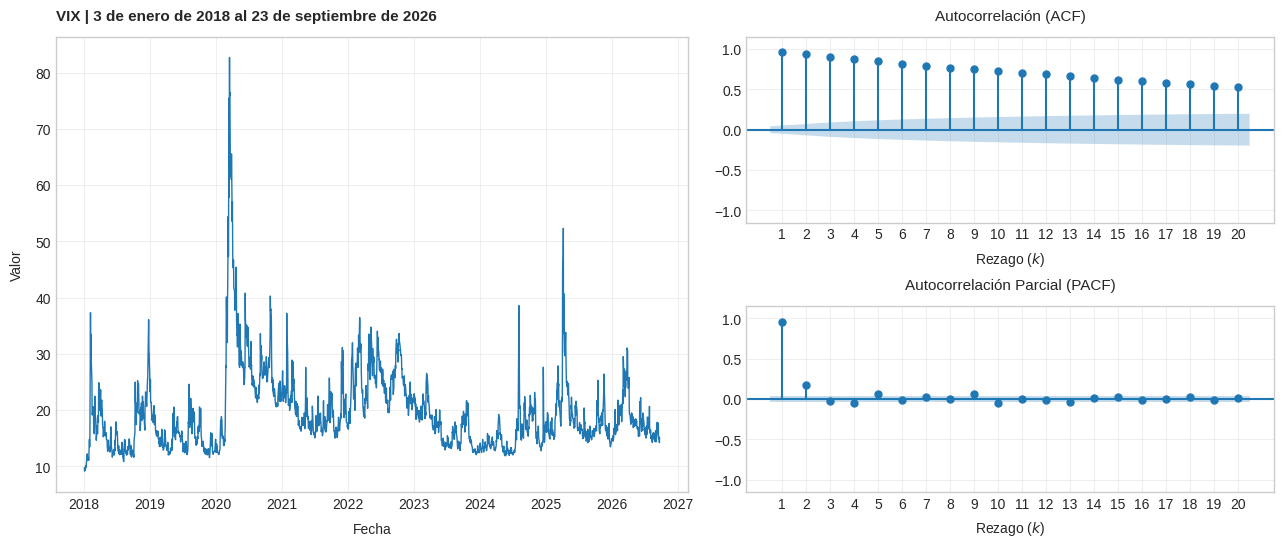

In [28]:
serie_vix = df["^VIX"].dropna()

# Gráficos
fig = plt.figure(figsize=(14, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], hspace=0.45, wspace=0.1)

lags_mostrar = 20

# COLUMNA 1: Serie del S&P 500
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(
    serie_vix.index,
    serie_vix.values,
    color="#1f77b4",
    linewidth=1,
)
ax1.set_title(
    'VIX | 3 de enero de 2018 al 23 de septiembre de 2026', loc='left',
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("Fecha", labelpad=8)
ax1.set_ylabel("Valor", labelpad=8)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): ACF
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(
    serie_vix,
    ax=ax2,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación (ACF)",
)
ax2.set_title("Autocorrelación (ACF)", fontsize=11, pad=12)
ax2.set_xlabel("Rezago ($k$)", labelpad=6)
ax2.set_xticks(range(1, lags_mostrar + 1))

ax2.set_ylim(-1.15, 1.15)
ax2.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (Inferior): PACF
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_vix,
    ax=ax3,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación Parcial (PACF)",
    method="ywm",
)
ax3.set_title("Autocorrelación Parcial (PACF)", fontsize=11, pad=12)
ax3.set_xlabel("Rezago ($k$)", labelpad=6)
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.15, 1.15)
ax3.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax3.grid(True, alpha=0.3)


plt.subplots_adjust(top=0.92, bottom=0.01, left=0.08, right=0.95)

plt.show()

## **Pregunta 4**

¿Es estacionaria la serie del VIX?

In [29]:
# PRUEBA ADF: VIX
adf_vix= adfuller(df['^VIX'])
print(f"VIX | p-value: {adf_vix[1]:.4f} | {'No Estacionaria' if adf_vix[1] >= 0.05 else 'Estacionaria'}")




VIX | p-value: 0.0000 | Estacionaria


## **Pregunta 5**

Separa los datos en conjunto de datos de entrenamiento (90%) y de prueba (10%)

In [30]:
serie_vix.index = pd.to_datetime(serie_vix.index, errors='coerce')
serie_vix = serie_vix.sort_index()

full_date_range = pd.bdate_range(start=serie_vix.index.min(), end=serie_vix.index.max(), freq='B')

serie_vix = serie_vix.reindex(full_date_range)

serie_vix.fillna(method='ffill', inplace=True)

serie_vix.dropna(inplace=True)

train_size = int(len(serie_vix) * 0.90)
train_vix = serie_vix.iloc[:train_size]
test_vix = serie_vix.iloc[train_size:]

In [31]:
test_vix.head()

,^VIX
2025-11-10,17.600000
2025-11-11,17.280001
2025-11-12,17.510000
2025-11-13,20.000000
2025-11-14,19.830000


In [32]:
test_vix.tail()

,^VIX
2026-09-17,15.44
2026-09-18,14.81
2026-09-21,14.87
2026-09-22,14.21
2026-09-23,15.18


## **Pregunta 6**

Usando la función `auto_arima` selecciona un modelo para la serie del VIX. ¿Eligen el mismo modelo los criterios de información de Akaike y el Bayesiano?

In [33]:
modelo_vix_aic = pm.auto_arima(
    train_vix, start_p=0, start_q=0, max_p=3, max_q=3,
    d=0, seasonal=False, information_criterion='aic',
    stepwise=True, suppress_warnings=True
)

print(f'Modelo óptimo por AIC: ARIMA{modelo_vix_aic.order}')
print(modelo_vix_aic.summary())

Modelo óptimo por AIC: ARIMA(2, 0, 3)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2049
Model:               SARIMAX(2, 0, 3)   Log Likelihood               -4362.456
Date:                Fri, 25 Sep 2026   AIC                           8738.911
Time:                        19:45:18   BIC                           8778.287
Sample:                    01-02-2018   HQIC                          8753.351
                         - 11-07-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2018      0.199      6.051      0.000       0.812       1.591
ar.L1          0.1243      0.046      2.711      0.007       0.034       0.214
ar.L2         

In [34]:
modelo_vix_bic = pm.auto_arima(
    train_vix, start_p=0, start_q=0, max_p=3, max_q=3,
    d=0, seasonal=False, information_criterion='bic',
    stepwise=True, suppress_warnings=True
)

print(f'Modelo óptimo por BIC: ARIMA{modelo_vix_bic.order}')
print(modelo_vix_bic.summary())

Modelo óptimo por BIC: ARIMA(2, 0, 3)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2049
Model:               SARIMAX(2, 0, 3)   Log Likelihood               -4362.456
Date:                Fri, 25 Sep 2026   AIC                           8738.911
Time:                        19:46:02   BIC                           8778.287
Sample:                    01-02-2018   HQIC                          8753.351
                         - 11-07-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2018      0.199      6.051      0.000       0.812       1.591
ar.L1          0.1243      0.046      2.711      0.007       0.034       0.214
ar.L2         

## **Pregunta 7**

Usando el modelo seleccionado ARIMA(2,0,3)
con intercepto, realiza proyecciones del VIX en el test set. Grafica la serie observada y predicha.

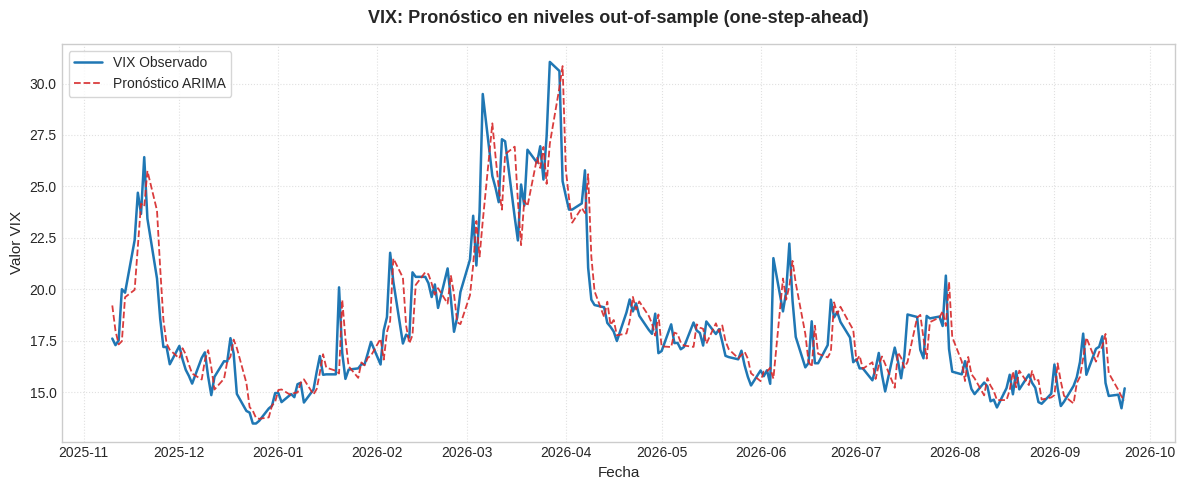

In [36]:
# Ajustar el modelo UNA SOLA VEZ con los datos de entrenamiento (con 'c' para intercepto)
model = SARIMAX(
    train_vix,
    order= (2,0,3),
    trend='c',  # Incluye el intercepto (constante)
    enforce_stationarity=False,
    enforce_invertibility=False,
)
model_fit = model.fit(disp=False);

# Extender la estructura del modelo a través del conjunto de prueba.
updated_model = model_fit.append(test_vix, refit=False);

# Extraer las predicciones 1-paso adelante alineadas con las fechas de test_vix
pred_vix = updated_model.fittedvalues.loc[test_vix.index]

# Crear el DataFrame de resultados
results_df = pd.DataFrame(
    {'VIX_Observado': test_vix, 'VIX_Predicho': pred_vix}, index=test_vix.index
)


plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.figure(figsize=(12, 5))

plt.plot(
    results_df.index,
    results_df['VIX_Observado'],
    label='VIX Observado',
    color='#1f77b4',
    linewidth=1.8,
)
plt.plot(
    results_df.index,
    results_df['VIX_Predicho'],
    label=f'Pronóstico ARIMA',
    color='#d62728',
    linestyle='--',
    linewidth=1.3,
    alpha=0.9,
)

plt.title(
    'VIX: Pronóstico en niveles out-of-sample (one-step-ahead)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Valor VIX', fontsize=11)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## **Pregunta 8**

Calcula el RMSE y MAE

In [37]:
rmse_vix = np.sqrt(
    np.mean((results_df['VIX_Observado'] - results_df['VIX_Predicho']) ** 2)
)

mae_vix = np.mean(
    np.abs(results_df['VIX_Observado'] - results_df['VIX_Predicho'])
)

print(f'RMSE: {rmse_vix:.2f}')
print(f'MAE: {mae_vix:.2f}')

RMSE: 1.50
MAE: 1.08
